# Wstęp



# Klasyczny model Isinga

$$
H(\bm{s}) = \sum_{(i, j) \in E(G)} J_{ij} s_i s_j + \sum_{i=1}^{N} h_i s_i
$$

## Przykład

W tych przykładach zaczniemy od utworzenia przykładowej instancji szkła spinowego. Następnie, używając tej instancji policzymy kilka przykładów. 

TODO: Write better

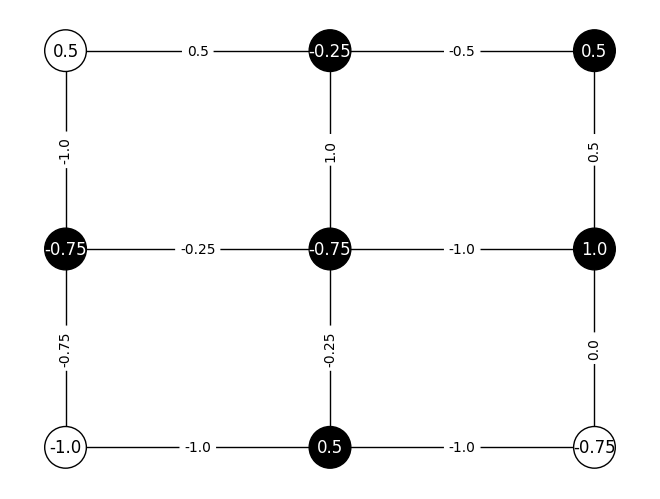

In [20]:
# Instancja szkła spinowego razem z obrazkiem

import random
import networkx as nx
import matplotlib.pyplot as plt

random.seed(7)

# Tworzymy graf
instance = nx.grid_2d_graph(3, 3)

# Nadajemy losowe wartości spinu, h i J
nx.set_node_attributes(instance, {node: random.choice([-1, 1]) for node in instance.nodes}, "spin")
nx.set_node_attributes(instance, {node: random.choice([i / 4 for i in range(-4, 5)]) for node in instance.nodes}, "h")
nx.set_edge_attributes(instance, {edge: random.choice([i / 4 for i in range(-4, 5)]) for edge in instance.edges}, "J")

# Ustalamy kolor wierzchołków w zalezności od wartości spinu, -1 (dół) czarny i +1 (góra) biały
node_colors = ["white" if instance.nodes[node]["spin"] == 1 else "black" for node in instance.nodes]


# Rysujemy instancje której będziemy używać
pos={node: node for node in instance.nodes}
nx.draw(instance, pos, node_color=node_colors,  node_size=900, font_weight='bold')

# rysujemy wierzchołki i pokazujemy wartość h na nich
node_labels = {node: f"{instance.nodes[node]['h']}" for node in instance.nodes}
for node in instance.nodes:
    label = f"{instance.nodes[node]['h']}"
    x, y = pos[node]  
    font_color = "white" if instance.nodes[node]["spin"] == -1 else "black"
    plt.text(x, y, label, fontsize=12, ha='center', va='center', color=font_color)
ax = plt.gca() # to get the current axis
ax.collections[0].set_edgecolor("black") 

# Rysujemy wartości "J" na krawędziach
edge_labels = {(u, v): f"{data['J']}" for u, v, data in instance.edges(data=True)}
nx.draw_networkx_edge_labels(instance, pos, edge_labels=edge_labels)

plt.show()

In [30]:
# Liczenie Energii prosto ze wzoru

spins = {node: instance.nodes[node]["spin"] for node in instance.nodes}
h = {node: instance.nodes[node]["h"] for node in instance.nodes}
J = {(u, v): data['J'] for u, v, data in instance.edges(data=True)}

# Liczymy w dwóch pętlach
energy_naive = 0

# Część liniowa
for node in instance.nodes:
    energy_naive += spins[node] * h[node]

# Część kwadratowa
for (u, v) in instance.edges:
    energy_naive += spins[u] * spins[v] * J[(u, v)]

print(f"Wartość energi wynosi: {energy_naive}")



Wartość energi wynosi: 1.25


## Inny sposób
Z punktu widzenia obliczeń, spojrzenie na model Isinga w kategoriach algebry liniowej może być łatwiejsze. Analizujemy macierz sąsiedztwa grafu $G$ i traktujemy każdy $J_{ij}$ jako wagę przypisaną do krawędzi. Ponieważ $G$ jest grafem nieskierowanym,  $J_{ij} = J_{ji}$. Aby uniknąć zbędnej pracy, możemy traktować tę macierz jako macierz górnotrójkątną i zajmować się jedynie elementami $J_{ij}$, gdzie $i < j$. Zwyczajowo tę macierz oznacza się jako $\bm{J}$. Dodatkowo możemy uporządkować wartości $h_i$ w wektor $\bm{h}$. Wówczas równanie dla $H(\bm{s})$ przyjmuje postać:

$$
H(\bm{s}) = \bm{s}\bm{J}\bm{s}^{T} + \bm{h}\bm{s}^{T}
$$


In [ ]:
# Liczenie energi używając algebry liniowej
import numpy as np

# Zamiana grafowej reprezentacji na macierzową. 
# UWAGA: od wersji python 3.7 słowniki zachowują kolejność, więc możemy bezpiecznie zamieniać je na vektory
def dict_to_vect(d: dict):
    return np.array(list(d.values()))

spins_vector = dict_to_vect(spins)
h_vector = dict_to_vect(h)

# Macierz górnotrójkątna J
def dict_to_matrix(instance: nx.Graph, J: dict):
    n = len(instance)
    J_matrix = np.zeros(shape=(n,n))
    renum = {node: idx for idx, node in enumerate(instance.nodes)}
    for (u, v), J_value in J.items():
        i = renum[u]
        j = renum[v]
        if i > j:
            i, j = j, i
        J_matrix[i, j] = J_value
    return J_matrix

J_matrix = dict_to_matrix(instance, J)

# Liczymy energię z kolejnego wzoru
energy_vectorized = spins_vector @ J_matrix @ spins_vector.T + spins_vector @ h_vector
print(f"Wartość energi wynosi: {energy_vectorized}")



Wartość energi wynosi: 1.25


### Dlaczego warto ten sposób stosować

Dla dużych instancji liczenie energi macierzowo jest szybsze

In [ ]:
import time

# Przygotujmy dużą losową instancję


# Literatura

- Any textbook for statistical mechanic (ex. Luca Peliti: Statistical Mechanics in a Nutshell, R.J. Baxter: Exactly Solved Models in Statistical Mechanics, H.E. Stanley: Introduction to Phase Transitions and Critical Phenomena etc.)
- Cipra, B. A. (1987). An introduction to the Ising model. *The American Mathematical Monthly*, 94(10), 937-959.
